# Simple Question answering langgraph

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict
from dotenv import load_dotenv

## Define model

In [2]:
model = ChatOllama(
    model="qwen2.5:0.5b",
    temperature=0
)


## Define state

In [4]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str 

In [8]:
def create_outline(state: BlogState) -> BlogState:

    title = state['title']

    result = model.invoke(f"write detailed outlines about this topic: {title}").content

    state['outline'] = result
    return state

In [9]:
def create_content(state: BlogState) -> BlogState:

    outline = state["outline"]

    result = model.invoke(f"Create a detailed about this topic {state['outline']} using these outtline {state['outline']}").content

    state['content'] = result

    return state


## Define graph

In [12]:
graph = StateGraph(BlogState)

# define nodes 

graph.add_node("create_outline", create_outline)
graph.add_node("create_content", create_content)


# define egdess 
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_content')
graph.add_edge('create_content', END)

# complie graph 
workflow = graph.compile()

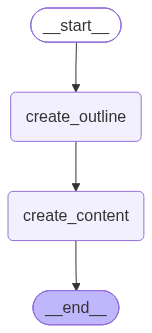

In [13]:
workflow

In [14]:
inital_state = {'title': "what about the war between usa and iran"}

workflow.invoke(inital_state)

{'title': 'what about the war between usa and iran',
 'outline': 'Certainly! Here are detailed outlines for the topic "What About the War Between the USA and Iran?"\n\n### 1. Introduction\n- **Definition**: The war between the United States and Iran is a complex and ongoing conflict that has been ongoing since the 1980s.\n- **Historical Context**: The conflict began with the 1980 Iran-Iraq War, which was a direct confrontation between the two countries over the sovereignty of the Garmeh oil fields in Iran.\n- **Current Status**: The war has escalated into a full-scale conflict, with both sides engaged in extensive military operations and diplomatic efforts.\n\n### 2. Background\n- **Historical Context**: The conflict began with the 1980 Iran-Iraq War, which was a direct confrontation between the two countries over the sovereignty of the Garmeh oil fields in Iran.\n- **Current Status**: The war has escalated into a full-scale conflict, with both sides engaged in extensive military opera